In [1]:
import pandas as pd
import numpy as np
from sklearn. linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [2]:
data = load_diabetes()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [5]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
#spliting the data into train test split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=41)

In [7]:
#store coefficient and r2score
coef = []
r2score = []

for i in [0, 0.1, 1, 10]:
    L = Lasso(alpha=i)
    L.fit(X_train, y_train)
    coef.append(L.coef_.tolist())
    y_pred = L.predict(X_test)
    r2score.append(r2_score(y_test, y_pred))

print(coef)
print(r2score)

[[-39.4083369595629, -257.3089757486337, 541.1065179476226, 277.064066230056, -1147.7818354286796, 718.0013859120563, 238.30973110723946, 266.64758957206294, 828.9320052261116, 118.54249528300207], [-0.0, -170.18320696120432, 539.9868779353259, 214.17751669749256, -82.20836486845484, -0.0, -239.60788481033262, 0.0, 459.0646698657209, 83.71281098062823], [0.0, -0.0, 401.51568540111657, 0.0, 0.0, 0.0, -0.0, 0.0, 254.84476407178755, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0]]
[0.5052064197516839, 0.529153278875006, 0.3548260401859057, -0.03061664566939304]


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.070e+05, tolerance: 2.082e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/

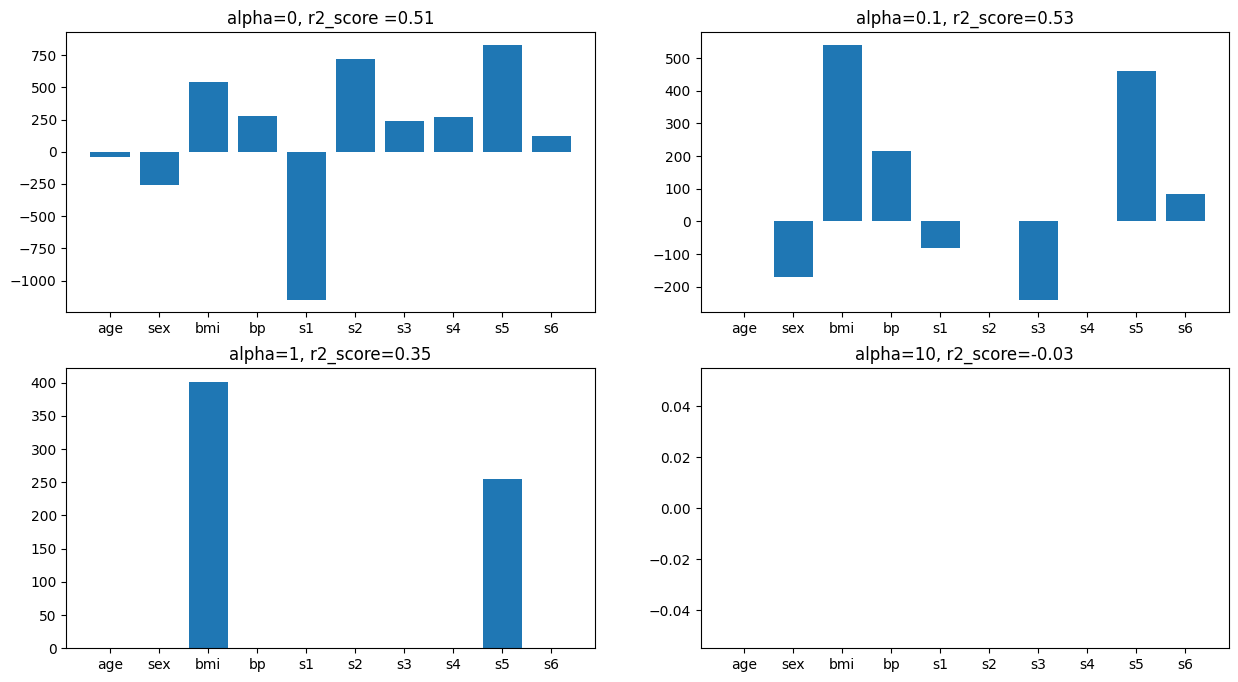

In [13]:
#creating subplot
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.bar(data.feature_names, coef[0])
plt.title('alpha=0, r2_score ={}'.format(round(r2score[0], 2)))

plt.subplot(2, 2, 2)
plt.bar(data.feature_names, coef[1])
plt.title('alpha=0.1, r2_score={}'.format(round(r2score[1], 2)))

plt.subplot(2, 2, 3)
plt.bar(data.feature_names, coef[2])
plt.title('alpha=1, r2_score={}'.format(round(r2score[2], 2)))

plt.subplot(2, 2, 4)
plt.bar(data.feature_names, coef[3])
plt.title('alpha=10, r2_score={}'.format(round(r2score[3], 2)))

plt.show()